# Analyse des patches satellites (GeoLifeCLEF 2025)

Ce notebook explore les images satellites TIFF du challenge. Chaque patch est :
- **Format** : TIFF 4 bandes (R, G, B, NIR), entiers int16
- **Taille** : 64×64 pixels à 10m de résolution → zone de **640m × 640m**
- **Source** : Sentinel-2 (Ecodatacube)
- **Accès** : `PA-train/{CD}/{AB}/{surveyId}.tiff` où AB et CD sont les 4 derniers chiffres du `surveyId`

## 0. Imports & configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import rasterio
from rasterio.plot import show
import warnings
warnings.filterwarnings('ignore')

# Racine du projet (adapter si besoin)
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
PA_TRAIN_DIR  = os.path.join(ROOT, 'data', 'SatelitePatches', 'PA-train')
PA_META_PATH  = os.path.join(ROOT, 'data', 'GLC25_PA_metadata_train.csv')

print('ROOT       :', ROOT)
print('Patches dir:', PA_TRAIN_DIR)
print('Metadata   :', PA_META_PATH)

ROOT       : /Users/justinemanuel/Documents/GitHub/Challenge_Deep_Learning
Patches dir: /Users/justinemanuel/Documents/GitHub/Challenge_Deep_Learning/data/SatelitePatches/PA-train
Metadata   : /Users/justinemanuel/Documents/GitHub/Challenge_Deep_Learning/data/GLC25_PA_metadata_train.csv


## 1. Chargement des métadonnées PA

In [2]:
df = pd.read_csv(PA_META_PATH)
print(f'Lignes : {len(df):,}  |  Colonnes : {list(df.columns)}')
print(f'surveyId uniques : {df["surveyId"].nunique():,}')
print(f'speciesId uniques : {df["speciesId"].nunique():,}')
df.head()

Lignes : 1,483,637  |  Colonnes : ['lon', 'lat', 'year', 'geoUncertaintyInM', 'areaInM2', 'region', 'country', 'speciesId', 'surveyId']
surveyId uniques : 88,987
speciesId uniques : 5,016


,lon,lat,year,geoUncertaintyInM,areaInM2,region,country,speciesId,surveyId
0,3.099038,43.134956,2021,5.0,100.0,MEDITERRANEAN,France,6874.0,212
1,3.099038,43.134956,2021,5.0,100.0,MEDITERRANEAN,France,476.0,212
2,3.099038,43.134956,2021,5.0,100.0,MEDITERRANEAN,France,11157.0,212
3,3.099038,43.134956,2021,5.0,100.0,MEDITERRANEAN,France,8784.0,212
4,3.099038,43.134956,2021,5.0,100.0,MEDITERRANEAN,France,4530.0,212


In [3]:
# Résumé par région
print('Observations par région :')
print(df['region'].value_counts())

Observations par région :
region
CONTINENTAL      773578
ATLANTIC         506288
MEDITERRANEAN    123112
ALPINE            62457
BOREAL            11723
PANNONIAN          5985
STEPPIC             460
BLACK SEA            34
Name: count, dtype: int64


## 2. Fonction utilitaire : surveyId → chemin TIFF

Règle du challenge : `…/{CD}/{AB}/{surveyId}.tiff`  
où **AB** = chiffres 3 et 4 depuis la droite, **CD** = 2 derniers chiffres.  
Exemple : `surveyId=3018575` → `./75/85/3018575.tiff`

In [4]:
def get_tiff_path(survey_id: int, base_dir: str = PA_TRAIN_DIR) -> str:
    """Retourne le chemin absolu vers le TIFF d'un surveyId."""
    s = str(survey_id)
    cd = s[-2:] if len(s) >= 2 else s          # 2 derniers chiffres
    ab = s[-4:-2] if len(s) >= 4 else s[:-2] if len(s) > 2 else s[0] if len(s) == 3 else ''
    return os.path.join(base_dir, cd, ab, f'{survey_id}.tiff')


def load_patch(survey_id: int, base_dir: str = PA_TRAIN_DIR) -> np.ndarray:
    """Charge un patch TIFF et retourne un array (4, 64, 64) int16."""
    path = get_tiff_path(survey_id, base_dir)
    with rasterio.open(path) as src:
        return src.read()   # shape (4, H, W)


# Vérification rapide
test_id = df['surveyId'].iloc[0]
print(f'surveyId {test_id} → {get_tiff_path(test_id)}')
print('Fichier existe :', os.path.exists(get_tiff_path(test_id)))

surveyId 212 → /Users/justinemanuel/Documents/GitHub/Challenge_Deep_Learning/data/SatelitePatches/PA-train/12/2/212.tiff
Fichier existe : True


## 3. Inspection d'un patch individuel

In [5]:
BANDS = {0: 'Red', 1: 'Green', 2: 'Blue', 3: 'NIR'}

sid = df['surveyId'].iloc[0]
path = get_tiff_path(sid)

with rasterio.open(path) as src:
    meta = src.meta
    crs  = src.crs
    patch = src.read()   # (4, 64, 64)

print(f'surveyId : {sid}')
print(f'Shape    : {patch.shape}  (bandes, hauteur, largeur)')
print(f'Dtype    : {patch.dtype}')
print(f'CRS      : {crs}')
print()
for i, name in BANDS.items():
    b = patch[i]
    print(f'  Bande {i+1} ({name:5s}) : min={b.min():5d}  max={b.max():5d}  mean={b.mean():7.1f}  std={b.std():.1f}')

surveyId : 212
Shape    : (4, 64, 64)  (bandes, hauteur, largeur)
Dtype    : int16
CRS      : IGNF:ETRS89LAEA

  Bande 1 (Red  ) : min=  258  max= 2455  mean=  645.6  std=294.5
  Bande 2 (Green) : min=  369  max= 2053  mean=  669.2  std=225.2
  Bande 3 (Blue ) : min=  210  max= 1598  mean=  435.7  std=198.2
  Bande 4 (NIR  ) : min= 1310  max= 3231  mean= 1895.6  std=228.8


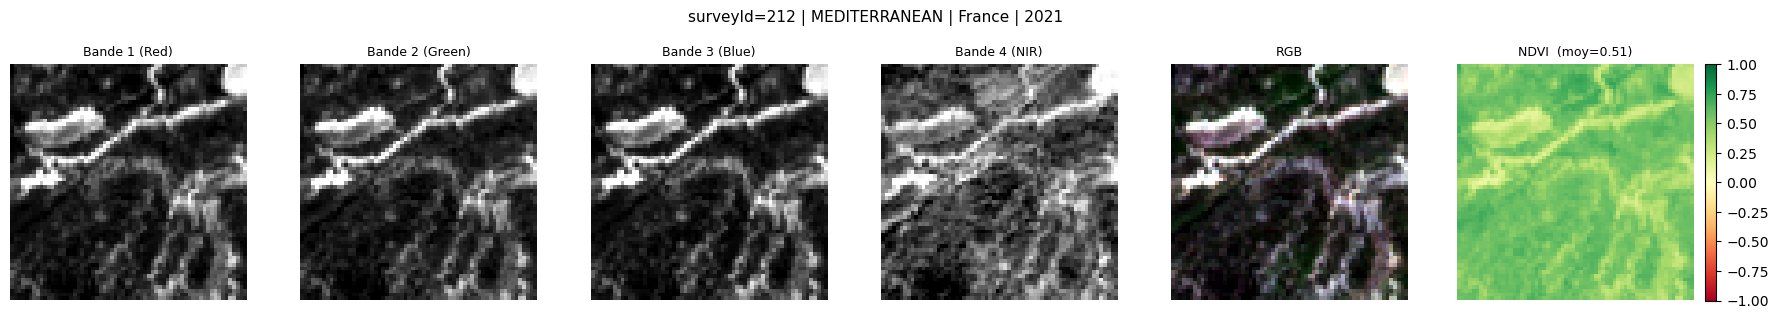

In [6]:
def normalize_band(arr: np.ndarray, p_low: float = 2, p_high: float = 98) -> np.ndarray:
    """Normalisation percentile [0, 1] pour affichage."""
    lo, hi = np.percentile(arr, p_low), np.percentile(arr, p_high)
    if hi == lo:
        return np.zeros_like(arr, dtype=float)
    return np.clip((arr.astype(float) - lo) / (hi - lo), 0, 1)


def patch_to_rgb(patch: np.ndarray) -> np.ndarray:
    """Convertit les 3 premières bandes en image RGB normalisée (H, W, 3)."""
    r = normalize_band(patch[0])
    g = normalize_band(patch[1])
    b = normalize_band(patch[2])
    return np.stack([r, g, b], axis=-1)


def compute_ndvi(patch: np.ndarray) -> np.ndarray:
    """NDVI = (NIR - Red) / (NIR + Red). Retourne un array (64, 64)."""
    nir = patch[3].astype(float)
    red = patch[0].astype(float)
    denom = nir + red
    ndvi = np.where(denom > 0, (nir - red) / denom, 0.0)
    return ndvi


# Visualisation d'un patch : 4 bandes + RGB + NDVI
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
titles = ['Bande 1 (Red)', 'Bande 2 (Green)', 'Bande 3 (Blue)', 'Bande 4 (NIR)', 'RGB', 'NDVI']

for i in range(4):
    axes[i].imshow(normalize_band(patch[i]), cmap='gray')
    axes[i].set_title(titles[i], fontsize=9)
    axes[i].axis('off')

axes[4].imshow(patch_to_rgb(patch))
axes[4].set_title('RGB', fontsize=9)
axes[4].axis('off')

ndvi = compute_ndvi(patch)
im = axes[5].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
axes[5].set_title(f'NDVI  (moy={ndvi.mean():.2f})', fontsize=9)
axes[5].axis('off')
plt.colorbar(im, ax=axes[5], fraction=0.046, pad=0.04)

meta_row = df[df['surveyId'] == sid].iloc[0]
fig.suptitle(
    f'surveyId={sid} | {meta_row["region"]} | {meta_row["country"]} | {meta_row["year"]}',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

## 4. Grille de 12 exemples aléatoires (RGB + NDVI)

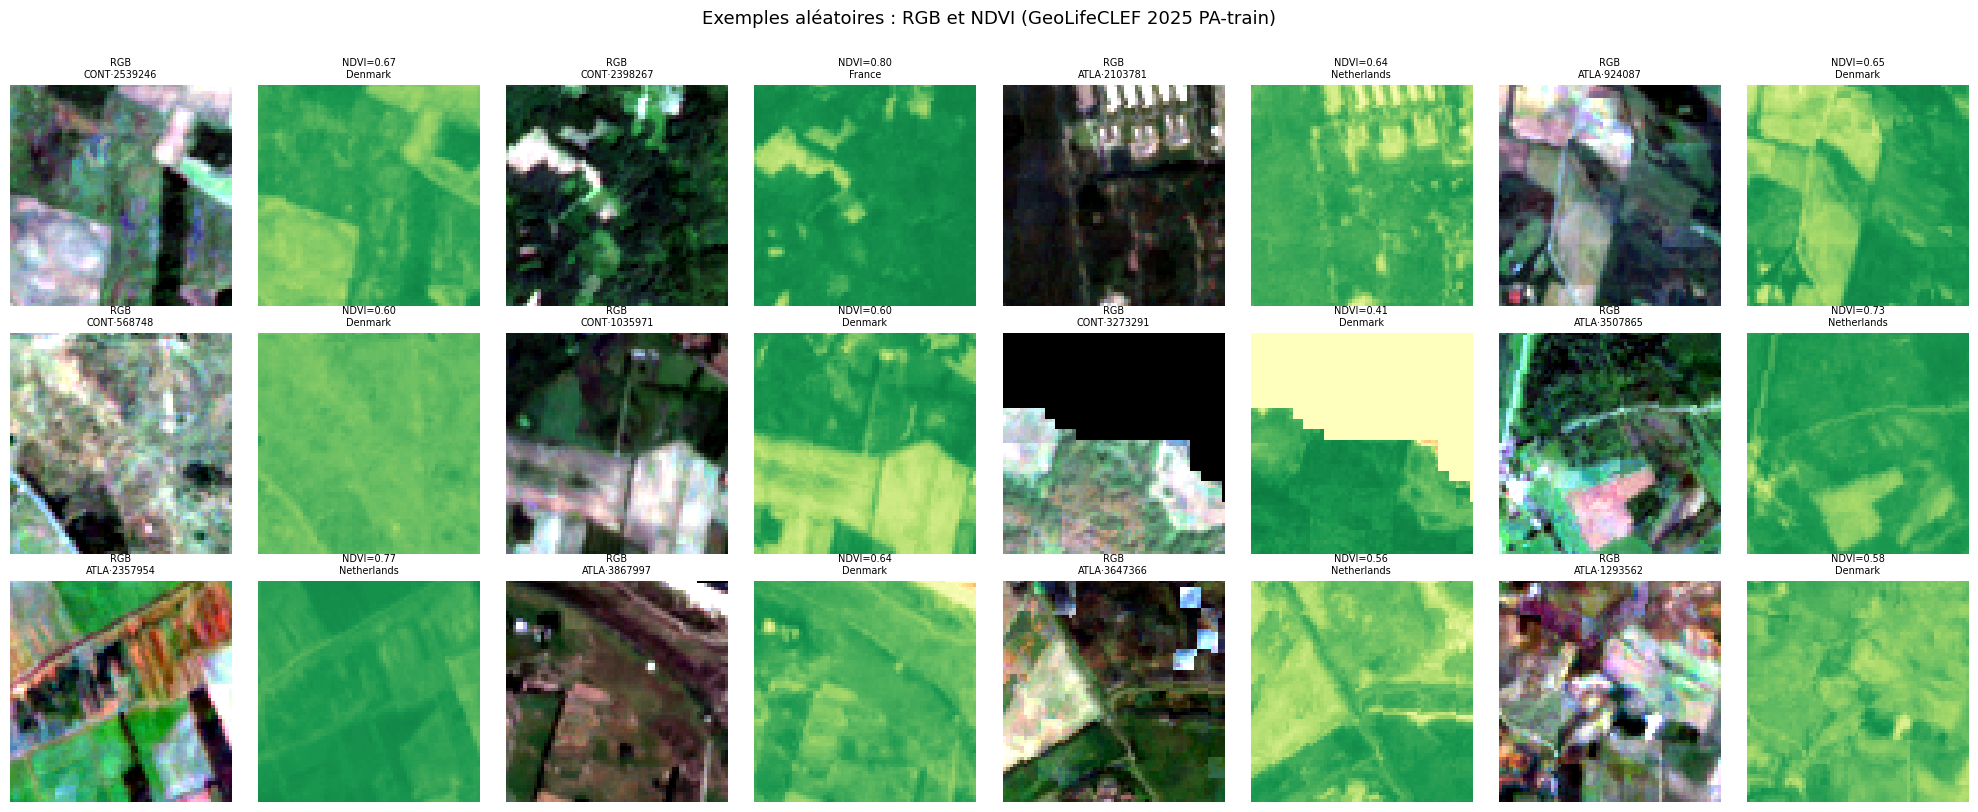

In [7]:
np.random.seed(42)
unique_surveys = df.drop_duplicates('surveyId')
sample = unique_surveys.sample(12)

fig, axes = plt.subplots(3, 8, figsize=(20, 8))
# Colonnes paires = RGB, colonnes impaires = NDVI

for idx, (_, row) in enumerate(sample.iterrows()):
    col_rgb  = (idx % 4) * 2
    col_ndvi = col_rgb + 1
    row_ax   = idx // 4

    try:
        p = load_patch(row['surveyId'])
    except Exception as e:
        print(f'Erreur surveyId {row["surveyId"]}: {e}')
        continue

    axes[row_ax, col_rgb].imshow(patch_to_rgb(p))
    axes[row_ax, col_rgb].set_title(f'RGB\n{row["region"][:4]}·{row["surveyId"]}', fontsize=7)
    axes[row_ax, col_rgb].axis('off')

    ndvi = compute_ndvi(p)
    axes[row_ax, col_ndvi].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    axes[row_ax, col_ndvi].set_title(f'NDVI={ndvi.mean():.2f}\n{row["country"]}', fontsize=7)
    axes[row_ax, col_ndvi].axis('off')

plt.suptitle('Exemples aléatoires : RGB et NDVI (GeoLifeCLEF 2025 PA-train)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Comparaison par région biogéographique

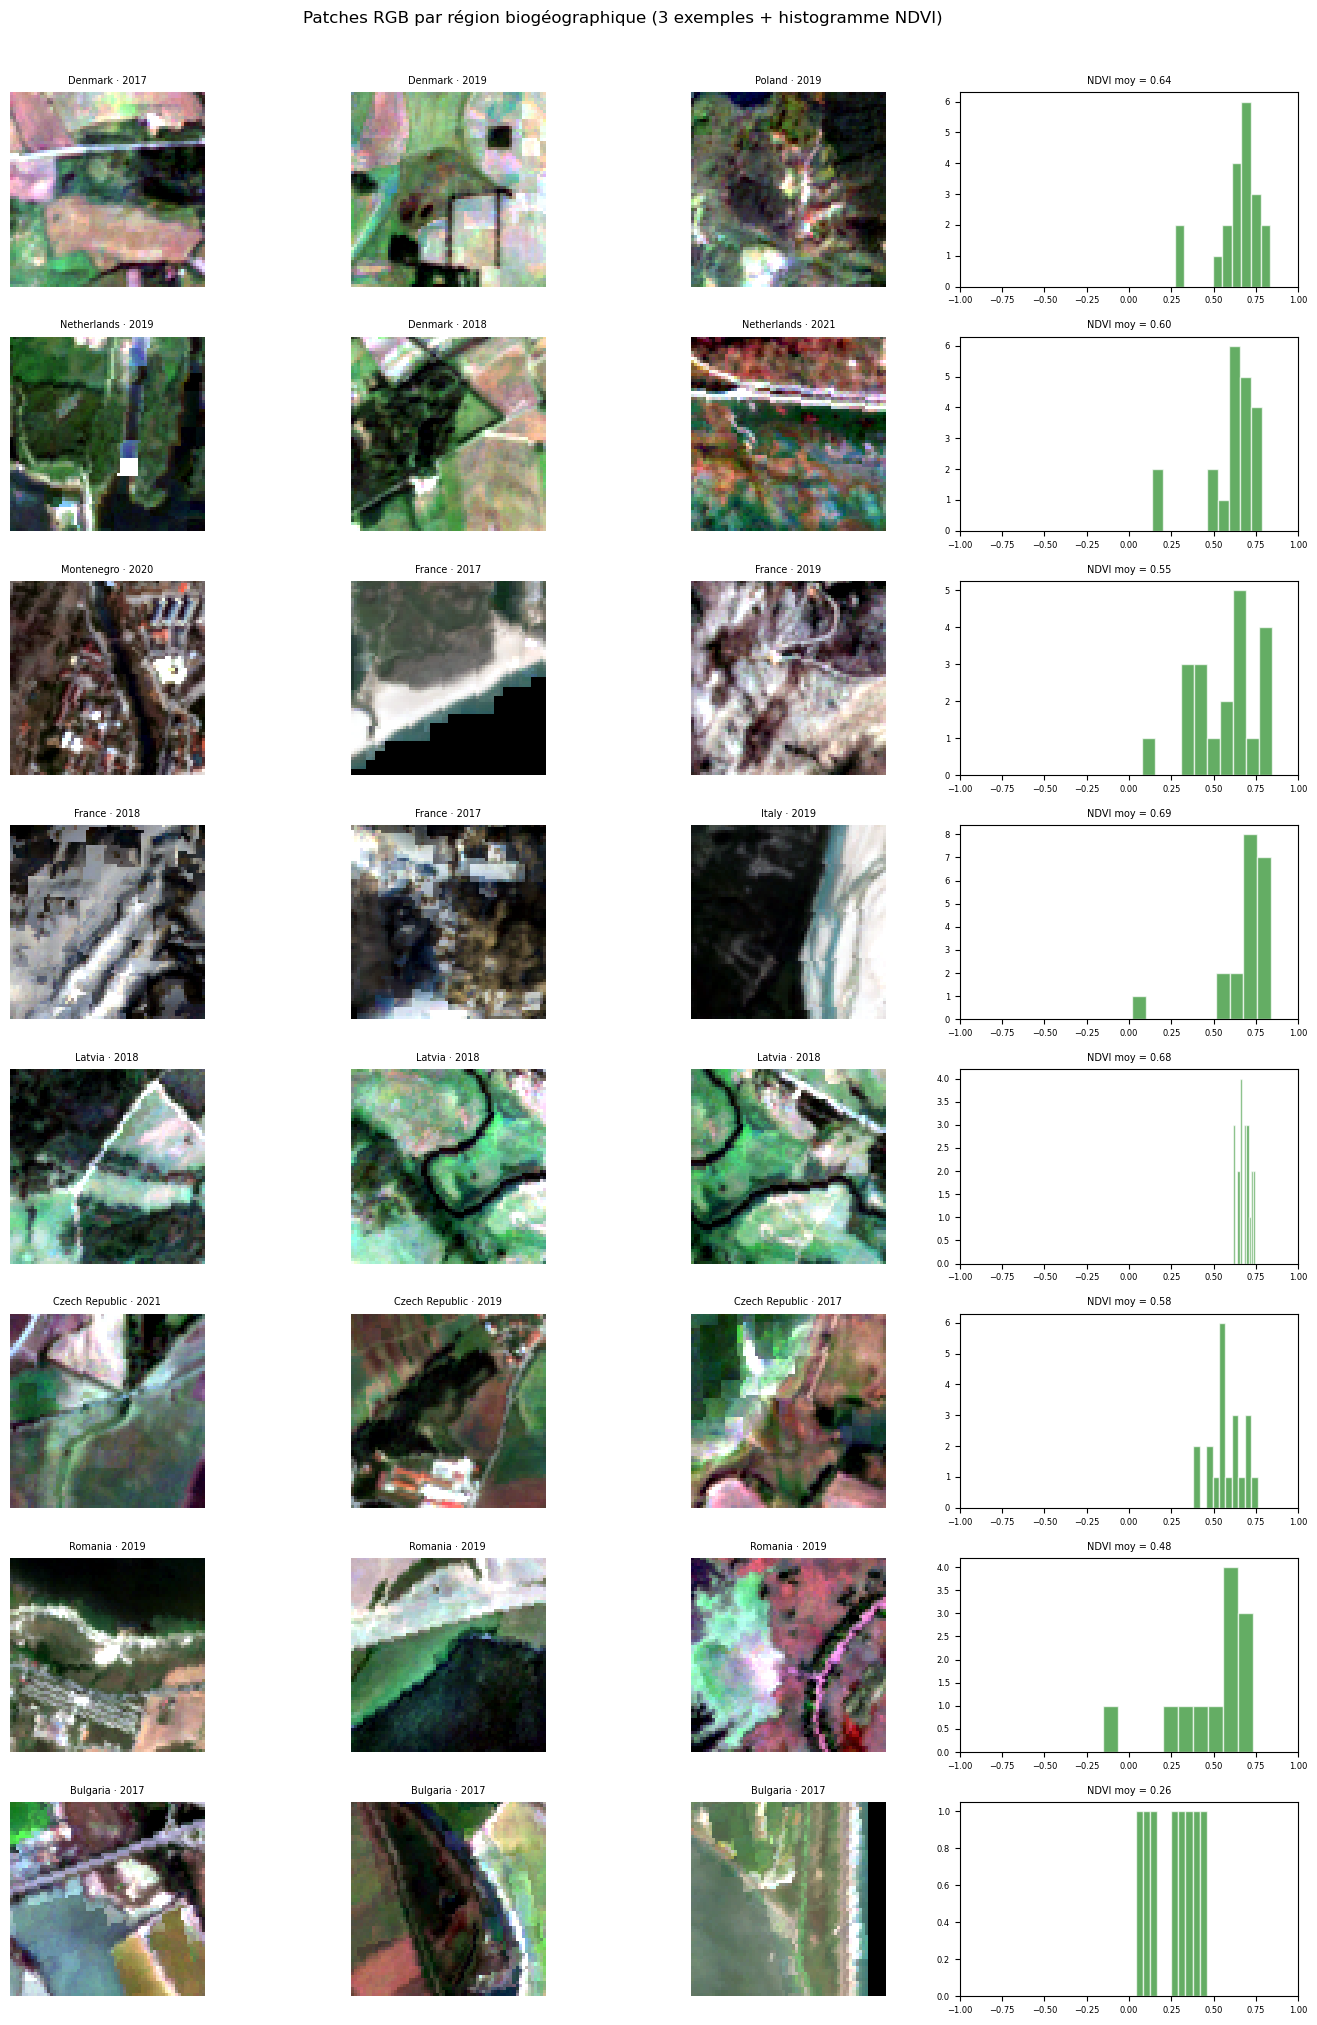

In [8]:
regions = df['region'].value_counts().index.tolist()
n_regions = len(regions)

fig, axes = plt.subplots(n_regions, 4, figsize=(14, n_regions * 2.5))

for r_idx, region in enumerate(regions):
    region_df = df[df['region'] == region].drop_duplicates('surveyId')
    row_sample = region_df.sample(min(3, len(region_df)), random_state=r_idx)

    axes[r_idx, 0].set_ylabel(region, rotation=90, fontsize=9, labelpad=5)
    axes[r_idx, 0].yaxis.label.set_visible(True)

    col = 0
    for _, obs in row_sample.iterrows():
        try:
            p = load_patch(obs['surveyId'])
            axes[r_idx, col].imshow(patch_to_rgb(p))
            axes[r_idx, col].set_title(f'{obs["country"]} · {obs["year"]}', fontsize=7)
        except:
            axes[r_idx, col].text(0.5, 0.5, 'N/A', ha='center', va='center', transform=axes[r_idx, col].transAxes)
        axes[r_idx, col].axis('off')
        col += 1

    # 4e colonne : NDVI moyen de la région (sur 20 patches max)
    ndvi_sample = region_df.sample(min(20, len(region_df)), random_state=42)
    ndvi_vals = []
    for _, obs in ndvi_sample.iterrows():
        try:
            p = load_patch(obs['surveyId'])
            ndvi_vals.append(compute_ndvi(p).mean())
        except:
            pass
    if ndvi_vals:
        axes[r_idx, 3].hist(ndvi_vals, bins=10, color='forestgreen', alpha=0.7, edgecolor='white')
        axes[r_idx, 3].set_title(f'NDVI moy = {np.mean(ndvi_vals):.2f}', fontsize=7)
        axes[r_idx, 3].set_xlim(-1, 1)
        axes[r_idx, 3].tick_params(labelsize=6)
    axes[r_idx, 3].axis('on')

plt.suptitle('Patches RGB par région biogéographique (3 exemples + histogramme NDVI)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 6. Statistiques des bandes sur N patches

In [9]:
N_SAMPLE = 200  # augmenter pour plus de précision
np.random.seed(0)
sample_ids = df.drop_duplicates('surveyId')['surveyId'].sample(N_SAMPLE).values

band_means = {i: [] for i in range(4)}
band_stds  = {i: [] for i in range(4)}
ndvi_means = []
errors = 0

for sid in sample_ids:
    try:
        p = load_patch(sid)
        for i in range(4):
            band_means[i].append(p[i].mean())
            band_stds[i].append(p[i].std())
        ndvi_means.append(compute_ndvi(p).mean())
    except:
        errors += 1

print(f'Patches chargés : {len(ndvi_means)}/{N_SAMPLE}  |  Erreurs : {errors}')
print()
for i, name in BANDS.items():
    m = np.mean(band_means[i])
    s = np.mean(band_stds[i])
    print(f'  Bande {i+1} ({name:5s}) : mean pixel = {m:7.1f}  |  std intra-patch = {s:6.1f}')

Patches chargés : 200/200  |  Erreurs : 0

  Bande 1 (Red  ) : mean pixel =   661.1  |  std intra-patch =  275.5
  Bande 2 (Green) : mean pixel =   714.0  |  std intra-patch =  219.9
  Bande 3 (Blue ) : mean pixel =   490.2  |  std intra-patch =  183.9
  Bande 4 (NIR  ) : mean pixel =  2869.9  |  std intra-patch =  667.5


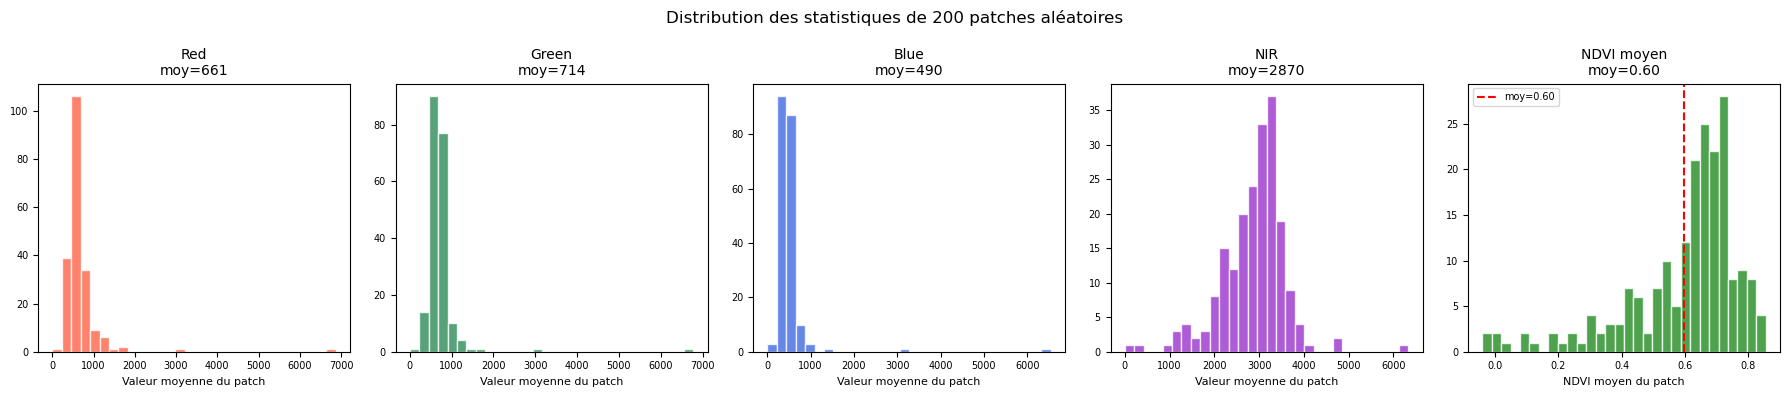

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
colors = ['tomato', 'seagreen', 'royalblue', 'darkorchid', 'olive']

for i, (name, color) in enumerate(zip(BANDS.values(), colors[:4])):
    axes[i].hist(band_means[i], bins=30, color=color, alpha=0.8, edgecolor='white')
    axes[i].set_title(f'{name}\nmoy={np.mean(band_means[i]):.0f}', fontsize=10)
    axes[i].set_xlabel('Valeur moyenne du patch', fontsize=8)
    axes[i].tick_params(labelsize=7)

axes[4].hist(ndvi_means, bins=30, color='forestgreen', alpha=0.8, edgecolor='white')
axes[4].axvline(np.mean(ndvi_means), color='red', linestyle='--', label=f'moy={np.mean(ndvi_means):.2f}')
axes[4].set_title(f'NDVI moyen\nmoy={np.mean(ndvi_means):.2f}', fontsize=10)
axes[4].set_xlabel('NDVI moyen du patch', fontsize=8)
axes[4].tick_params(labelsize=7)
axes[4].legend(fontsize=7)

plt.suptitle(f'Distribution des statistiques de {len(ndvi_means)} patches aléatoires', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Corrélation entre NDVI et présence d'espèces

On calcule le NDVI moyen par `surveyId` et on le croise avec le nombre d'espèces observées.

Patches avec richesse et NDVI : 200
Corrélation NDVI ↔ richesse spécifique : r = 0.062


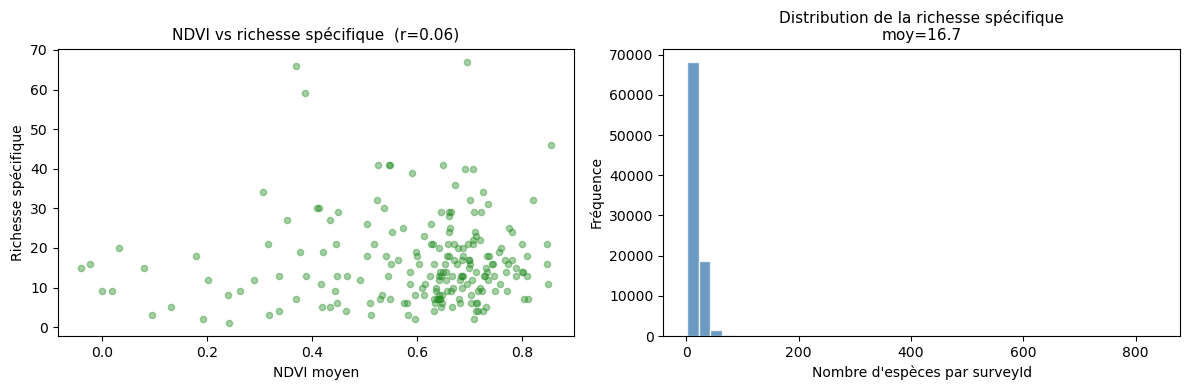

In [11]:
# Nombre d'espèces par surveyId (richesse spécifique)
species_richness = df.groupby('surveyId')['speciesId'].count().reset_index()
species_richness.columns = ['surveyId', 'n_species']

# NDVI moyen par surveyId (sur le sous-échantillon déjà calculé)
ndvi_df = pd.DataFrame({'surveyId': list(sample_ids[:len(ndvi_means)]), 'ndvi_mean': ndvi_means})

merged = ndvi_df.merge(species_richness, on='surveyId')
print(f'Patches avec richesse et NDVI : {len(merged)}')

corr = merged['ndvi_mean'].corr(merged['n_species'])
print(f'Corrélation NDVI ↔ richesse spécifique : r = {corr:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(merged['ndvi_mean'], merged['n_species'], alpha=0.4, s=20, color='forestgreen')
axes[0].set_xlabel('NDVI moyen', fontsize=10)
axes[0].set_ylabel('Richesse spécifique', fontsize=10)
axes[0].set_title(f'NDVI vs richesse spécifique  (r={corr:.2f})', fontsize=11)

# Distribution de la richesse
axes[1].hist(species_richness['n_species'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Nombre d\'espèces par surveyId', fontsize=10)
axes[1].set_ylabel('Fréquence', fontsize=10)
axes[1].set_title(f'Distribution de la richesse spécifique\nmoy={species_richness["n_species"].mean():.1f}', fontsize=11)

plt.tight_layout()
plt.show()

## 8. Visualisation cartographique des surveyIds échantillonnés

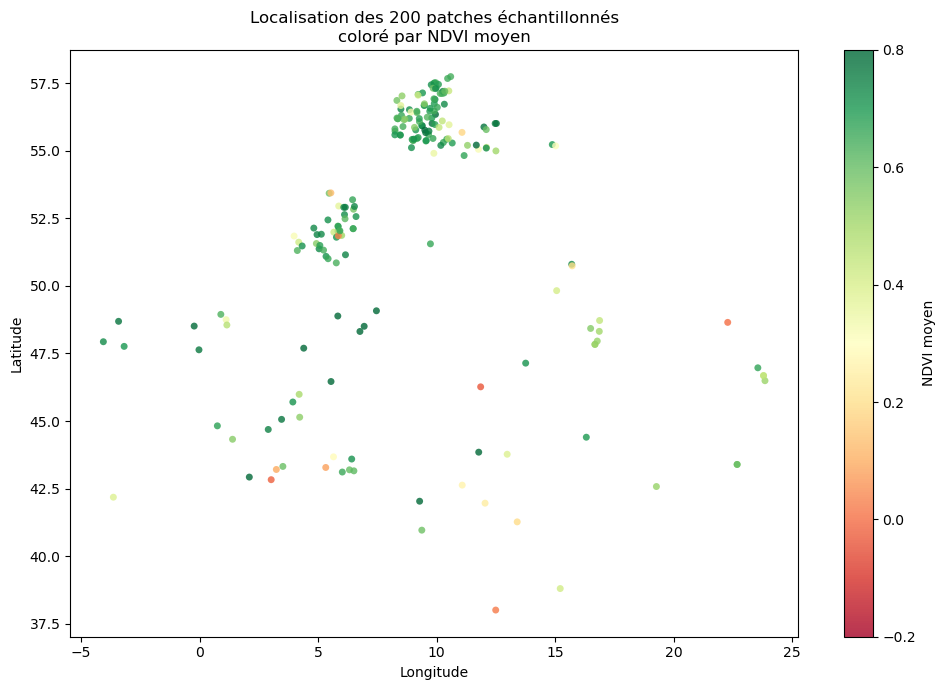

In [12]:
# Couverture géographique des patches (carte lon/lat)
sample_meta = df[df['surveyId'].isin(ndvi_df['surveyId'])].drop_duplicates('surveyId')
sample_meta = sample_meta.merge(ndvi_df, on='surveyId')

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    sample_meta['lon'], sample_meta['lat'],
    c=sample_meta['ndvi_mean'], cmap='RdYlGn',
    vmin=-0.2, vmax=0.8, s=25, alpha=0.8, edgecolors='none'
)
plt.colorbar(sc, ax=ax, label='NDVI moyen')
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.set_title(f'Localisation des {len(sample_meta)} patches échantillonnés\ncoloré par NDVI moyen', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Résumé et pistes pour la modélisation

### Ce qu'on a appris
| Aspect | Valeur |
|---|---|
| Format | TIFF int16, 4 bandes, 64×64 px |
| Résolution | 10m/px → 640m × 640m |
| Valeurs typiques | Red ~400-800, NIR ~2000-4000 |
| NDVI moyen | ~0.3–0.6 (végétation dominante en Europe) |
| Patches disponibles | 88 987 surveys uniques |
| Richesse spécifique | variable (1–30+ espèces par survey) |

### Pistes pour un modèle
1. **Baseline CNN** : traiter les 4 bandes comme une image (4, 64, 64) → ResNet/EfficientNet avec `in_channels=4`
2. **Normalisation** : calculer mean/std globaux sur ~1000 patches pour normaliser en z-score
3. **Augmentation** : rotation, flip horizontale/verticale (invariance spatiale)
4. **Multi-label** : chaque surveyId peut avoir plusieurs espèces → sortie sigmoid (pas softmax)
5. **Fusion modale** : combiner patches + variables environnementales CSV pour améliorer les prédictions